# Lindblad 动力学的随机 Magnus 变分量子模拟

本教程完整演示 `pyqpanda_alg.LindbladMagnus` 模块的算法原理与工程使用，
对应论文

> Jia-Cheng Huang, Hao-En Li, Yi-Cheng Wang, Guang-Ze Zhang, Jun Li, Han-Shi Hu,
> **Towards Robust Variational Quantum Simulation of Lindblad Dynamics via
> Stochastic Magnus Expansion**, *PRX Quantum* 6, 040312 (2025).
> [arXiv:2503.22099](https://arxiv.org/abs/2503.22099)

整套实现（量子线路构造、态矢量模拟）均基于 **pyqpanda3**；数值部分仅依赖
`numpy` / `scipy`，**不引入 qiskit / qutip 等其它量子计算框架**。参考实现
[`Furthermore-F/LindbladMagnus`](https://github.com/Furthermore-F/LindbladMagnus)
的算法思路被沿用，但具体电路与数值实现完全基于 pyqpanda3 生态。

### 学习目标

1. 理解开量子系统 Lindblad 动力学的 **量子态扩散（QSD）unravavelling**；
2. 掌握 **随机 Magnus 展开（Scheme I–IV）** 如何生成每一步的有效哈密顿量；
3. 理解 **McLachlan 变分原理** 在非厄米 $H_{\mathrm{eff}}$ 下的最小二乘形式；
4. 用 `LindbladMagnusSolver` 端到端地模拟 **TFIM 阻尼模型** 与 **FMO 光合复合体**；
5. 学会根据系统特性选择 `dt` / ansatz 层数 / 轨迹数 / Magnus 阶数。

## 1. 理论框架

### 1.1 Lindblad 主方程

开放量子系统的密度矩阵 $\rho(t)$ 服从 Lindblad 主方程

$$
\dot\rho = -i[H,\rho] + \sum_k \Big(L_k\rho L_k^\dagger
        - \tfrac{1}{2}\{L_k^\dagger L_k,\rho\}\Big),
$$

其中 $H$ 是厄米系统哈密顿量，$\{L_k\}$ 是 Lindblad 耗散算符。直接模拟 $\rho$
需要在 $d^2$ 维 Liouville 空间上积分，随比特数指数增长。

### 1.2 量子态扩散（QSD）unravelling

QSD 把主方程改写为 **纯态轨迹** 的随机微分方程（SDE），再对系综求平均：

$$
\rho(t) = \mathbb{E}\big[|\psi_\xi(t)\rangle\langle\psi_\xi(t)|\big].
$$

论文区采用 *nonlinear* QSD（保持 $\psi$ 归一化）：

$$
d|\psi\rangle = X_0\,|\psi\rangle\,dt + \sum_k (L_k - \langle L_k\rangle)|\psi\rangle\,d\xi_k,
$$

其中 $d\xi_k$ 是标准 Wiener 增量，$\langle\cdot\rangle\equiv\langle\psi|\cdot|\psi\rangle$，
而漂移算子

$$
X_0 = -iH + \sum_k\big[-\tfrac{1}{2}(L_k^\dagger+L_k)L_k
                       + 2\mathrm{Re}\langle L_k\rangle L_k\big].
$$

### 1.3 随机 Magnus 展开

一步 $[t,t+\Delta t]$ 上的传播子写为 $\exp(\Omega)$，$\Omega$ 由 Magnus 级数给出。
论文将多重随机积分（Wiener 增量 $\xi_k$、Lévy 区域 $a_{ij}$、高阶 iterated
integral $a_0, c_0$）用 **Brownian bridge Fourier 展开**（Kloeden–Platen）逼近，
得到 Scheme I–IV：

| Scheme | 阶 | 主要项 |
| --- | --- | --- |
| 0 (Euler–Maruyama) | 1/2 | $X_0 dt + \sum_k L_k \sqrt{dt}\,\xi_k$ |
| I | 1/2 | 同上但用矩阵指数传播 |
| II | 1.0 | + $[X_0, L_k]a_0\,dt/2 + [L_i,L_j]$ Lévy 项 |
| III | 1.5 | + 二重嵌套换位子 |
| IV | 2.0 | + 三重嵌套换位子 |

高阶 Scheme 允许 **更大时间步** 且显著 **降低轨迹数需求**——这是论文的核心贡献。

### 1.4 McLachlan 变分原理

由于 $H_{\mathrm{eff}}$ 非厄米，变分模拟需要在参数化流形
$|\psi(\boldsymbol\theta)\rangle$ 上最小化

$$
\Big\|\tfrac{\partial|\psi\rangle}{\partial t} + iH_{\mathrm{eff}}|\psi\rangle\Big\|^2
\quad\Rightarrow\quad
A\dot{\boldsymbol\theta} = -iB.
$$

其中 $A_{ij}=\langle\partial_i\psi_\perp|\partial_j\psi_\perp\rangle$，
$B_i=\langle\partial_i\psi_\perp|H_{\mathrm{eff}}|\psi\rangle$，
$|\partial_i\psi_\perp\rangle=(I-|\psi\rangle\langle\psi|)|\partial_i\psi\rangle$。
对实 $\dot{\boldsymbol\theta}$ 拆分实部/虚部，联立最小二乘求解：

$$
\begin{bmatrix}\mathrm{Re}\,A\\ \mathrm{Im}\,A\end{bmatrix}\dot{\boldsymbol\theta}
=
\begin{bmatrix}\mathrm{Im}\,B\\ -\mathrm{Re}\,B\end{bmatrix}.
$$

### 1.5 整体算法流程

```
对每条轨迹 ξ:
  对每个时间步 t → t+Δt:
    1) 采样 Wiener 积分 (ξ_k, a_0, a_ij, ...)
    2) 由 H, {L_k}, ψ(t) 用 Magnus 展开 → H_eff
    3) McLachlan 最小二乘 → dθ/dt
    4) RK4 积分 θ(t+Δt) = θ(t) + Δt·Φ(θ, H_eff)
    5) 更新归一化常数 N(t) 跟踪 norm decay (linear QSD)
对系综求平均: <O>(t) = mean_k <ψ_k(t)|O|ψ_k(t)>
```


## 2. 环境准备

`LindbladMagnus` 已随 `pyqpanda_alg` 一并安装。教程需要 `numpy`、`scipy`、
`matplotlib`；可选 `tqdm` 提供进度条。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyqpanda3
from pyqpanda_alg.LindbladMagnus import (
    # 顶层求解器
    LindbladMagnusSolver,
    LindbladResult,
    solve,
    # 物理模型
    fmo_model,
    tfim_model,
    rpm_model,
    # 精确解参考
    mesolve,
    liouvillian,
    # 算法内部
    effective_hamiltonian,
    sample_wiener_integrals,
    mclachlan_system,
    variational_step_rk4,
    variational_step_euler,
    # Ansatz
    HardwareEfficientAnsatz,
    VariationalAnsatz,
)

%matplotlib inline
print(f"pyqpanda3 version: {getattr(pyqpanda3, '__version__', 'unknown')}")
print("LindbladMagnus module imported successfully.")


pyqpanda3 version: 0.3.5
LindbladMagnus module imported successfully.


### 2.1 模块结构速查

| 文件 | 职责 |
| --- | --- |
| `magnus.py` | Scheme I–IV 随机 Magnus 积分器，返回非厄米 `H_eff` |
| `ansatz.py` | `VariationalAnsatz` / `HardwareEfficientAnsatz` |
| `variational.py` | McLachlan 最小二乘 + Euler / RK4 |
| `lindblad.py` | `LindbladMagnusSolver` + `LindbladResult` + 函数式 `solve` |
| `models.py` | FMO / TFIM / RPM 模型 + 自研 `mesolve` |

## 3. 精确参考：`mesolve`

我们自研的 `mesolve` 通过 Liouvillian 超算符向量化 + `scipy.integrate.solve_ivp`
求解 Lindblad 主方程，**完全替代 `qutip.mesolve`**。先用最简单的单比特振幅阻尼
验证：激发态布居应按 $e^{-\gamma t}$ 衰减。

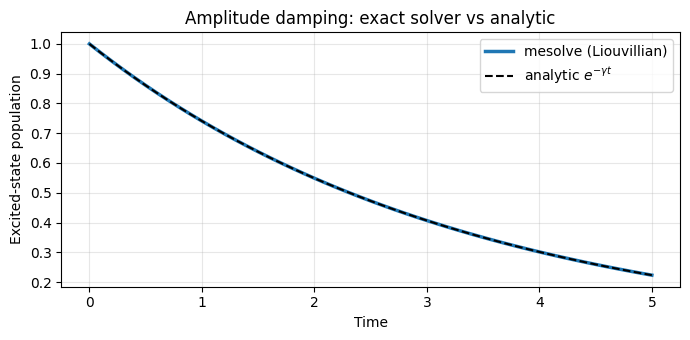

Max error vs analytic: 1.07e-10


In [2]:
gamma = 0.3
H0 = np.zeros((2, 2), dtype=complex)
L = np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex)  # |0><1|
psi0 = np.array([0, 1.0], dtype=complex)                    # |1> 激发态
tlist = np.linspace(0, 5, 51)
e_ops = [np.array([[0, 0], [0, 1]], dtype=complex)]          # |1><1|

expect = mesolve(H0, psi0, tlist, [L], e_ops)
analytic = np.exp(-gamma * tlist)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tlist, expect[0], lw=2.5, label='mesolve (Liouvillian)')
ax.plot(tlist, analytic, 'k--', label=r'analytic $e^{-\gamma t}$')
ax.set_xlabel('Time'); ax.set_ylabel('Excited-state population')
ax.set_title('Amplitude damping: exact solver vs analytic')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Max error vs analytic: {np.abs(expect[0] - analytic).max():.2e}")


**Liouvillian 自检**：$\mathcal{L}$ 是 trace-preserving 的，即
$\mathrm{Tr}(\mathcal{L}(\rho))=0$。对单位矩阵 $\rho=I$ 验证。

In [3]:
L_super = liouvillian(H0, [L])
I_vec = np.eye(2, dtype=complex).reshape(-1)
out = (L_super @ I_vec).reshape(2, 2)
print(f"Tr(L(I)) = {np.trace(out):.2e}  (should be ~0)")


Tr(L(I)) = 0.00e+00+0.00e+00j  (should be ~0)


## 4. 案例一：阻尼 TFIM 模型

横场 Ising 模型加振幅阻尼是最简单的多比特开放系统 benchmark：

$$
H = Z_0 Z_1 - \tfrac{1}{2}(X_0 + X_1), \qquad
L_0 = \sqrt{g}\,\sigma_- \otimes I, \quad L_1 = \sqrt{g}\,I\otimes\sigma_-,
$$

其中 $g=0.1$。从 $|11\rangle$ 出发，系统经历相干振荡同时缓慢弛豫到 $|00\rangle$。

In [4]:
H, c_ops, e_ops, psi0, labels = tfim_model()
print(f"Hamiltonian shape: {H.shape}")
print(f"Collapse operators: {len(c_ops)} (each damping one qubit)")
print(f"Observables:        {labels}")
print(f"Initial state:      |11>")
print(f"H =\n{np.round(H.real, 3)}")


Hamiltonian shape: (4, 4)
Collapse operators: 2 (each damping one qubit)
Observables:        ['|00>', '|11>', '|01>']
Initial state:      |11>
H =
[[ 1.  -0.5 -0.5  0. ]
 [-0.5 -1.   0.  -0.5]
 [-0.5  0.  -1.  -0.5]
 [ 0.  -0.5 -0.5  1. ]]


### 4.1 构造变分 ansatz

`HardwareEfficientAnsatz` 每层由 **RX-RZ 单比特旋转 + RZZ 双比特纠缠** 组成。
关键设计：所有参数化门在 $\theta=0$ 时为恒等，因此 ansatz 在零参数处自然保留
初态。

In [5]:
ansatz = HardwareEfficientAnsatz(n_qubits=2, layers=2, init_state=psi0)
print(f"Ansatz: {ansatz!r}")
print(f"Number of parameters: {ansatz.n_parameters}")

# 验证 theta=0 时确实复现 |11>
sv0 = ansatz.get_statevector(np.zeros(ansatz.n_parameters))
print(f"\nOverlap with |11>: {abs(np.vdot(psi0, sv0))**2:.6f}  (should be 1.0)")

# 查看对应的量子程序
print(f"\nCircuit summary: {ansatz.to_qprog().count_ops()}")


Ansatz: HardwareEfficientAnsatz(n_qubits=2, n_parameters=12, n_gates=12)
Number of parameters: 12

Overlap with |11>: 1.000000  (should be 1.0)

Circuit summary: {'RZ': 4, 'RZZ': 4, 'RX': 4, 'X': 2}


### 4.2 端到端模拟

构造 `LindbladMagnusSolver`，运行 30 条 nonlinear QSD 轨迹，与精确 Liouvillian
解对比。

In [6]:
times = np.linspace(0, 2.5, 51)   # dt = 0.05
traj_num = 30

# 精确参考
exact = mesolve(H, psi0, times, c_ops, e_ops)

# 变分 Lindblad-Magnus（Magnus order 1）
solver = LindbladMagnusSolver(H, c_ops, ansatz,
                              qsd_type='nonlinear',
                              magnus_order=1,
                              integrator='rk4')
result = solver.solve(psi0, times, e_ops,
                      traj_num=traj_num, seed=42, verbose='tqdm')

max_err = np.abs(result.expect - exact).max()
print(f"\nMagnus(1) max error vs exact: {max_err:.4f}")
print(f"Final populations:")
for i, lab in enumerate(labels):
    print(f"  {lab:>5}: exact={exact[i, -1]:.4f}  sim={result.expect[i, -1]:.4f}"
          f"  ±{result.std[i, -1]:.4f}")


trajectories:   0%|          | 0/30 [00:00<?, ?traj/s]

trajectories:   3%|▎         | 1/30 [00:00<00:10,  2.64traj/s]

trajectories:   7%|▋         | 2/30 [00:00<00:09,  2.93traj/s]

trajectories:  10%|█         | 3/30 [00:00<00:08,  3.27traj/s]

trajectories:  13%|█▎        | 4/30 [00:01<00:09,  2.84traj/s]

...

trajectories:  93%|█████████▎| 28/30 [00:07<00:00,  4.06traj/s]

trajectories:  97%|█████████▋| 29/30 [00:07<00:00,  4.25traj/s]

trajectories: 100%|██████████| 30/30 [00:08<00:00,  4.29traj/s]

trajectories: 100%|██████████| 30/30 [00:08<00:00,  3.67traj/s]


Magnus(1) max error vs exact: 0.0696
Final populations:
   |00>: exact=0.2272  sim=0.2113  ±0.1077
   |11>: exact=0.4893  sim=0.4793  ±0.1518
   |01>: exact=0.1417  sim=0.1730  ±0.1286


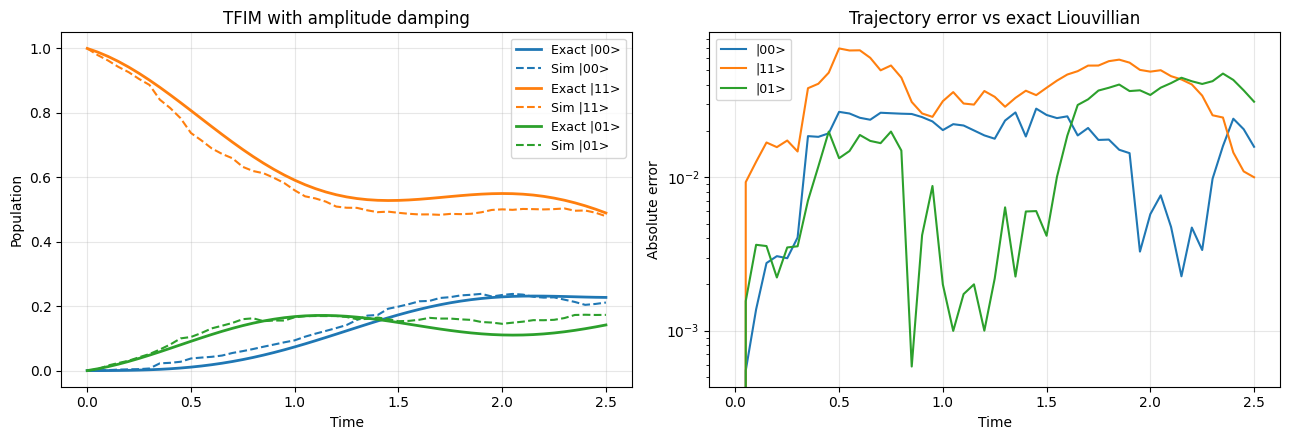

In [7]:
palette = plt.cm.tab10.colors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# 左：布居演化
for i, lab in enumerate(labels):
    ax1.plot(times, exact[i], '-', color=palette[i], lw=2, label=f'Exact {lab}')
    ax1.plot(times, result.expect[i], '--', color=palette[i], lw=1.5,
             label=f'Sim {lab}')
ax1.set_xlabel('Time'); ax1.set_ylabel('Population')
ax1.set_title('TFIM with amplitude damping')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# 右：误差曲线
for i, lab in enumerate(labels):
    err = np.abs(result.expect[i] - exact[i])
    ax2.plot(times, err, color=palette[i], label=lab, lw=1.5)
ax2.set_xlabel('Time'); ax2.set_ylabel('Absolute error')
ax2.set_title('Trajectory error vs exact Liouvillian')
ax2.legend(fontsize=9); ax2.set_yscale('log'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 5. 案例二：FMO 光合复合体

Fenna–Matthews–Olson (FMO) 复合体是光合作用中**环境辅助量子传输**的典范系统。
我们采用论文中使用的 5-site 子网络：

- **Hamiltonian**：5 个 site 之间的电子激发跳跃耦合（site 1–2–3 为主链）
- **7 个 Lindblad 算符**：
  - 3 个 dephasing（蛋白环境的纯退相，$\sqrt{a}\,|k\rangle\langle k|$）
  - 3 个 decay（辐射衰减到 ground，$\sqrt{b}\,|g\rangle\langle k|$）
  - 1 个 sink（不可逆传输到反应中心，$\sqrt{g}\,|s\rangle\langle 3|$）
- 初态 $|\psi_0\rangle = |\text{site 1}\rangle$

5 维物理 Hilbert 空间被 padding 到 3 比特 (8 维) 以适配量子线路。

In [8]:
H, c_ops, e_ops, psi0, labels = fmo_model()
print(f"FMO Hamiltonian shape: {H.shape}  (3 qubits, padded from 5-dim)")
print(f"Collapse operators:    {len(c_ops)}")
print(f"  - 3 dephasing:   sqrt(a) |site_k><site_k|,  a = 3e-3")
print(f"  - 3 decay:       sqrt(b) |ground><site_k|, b = 5e-7")
print(f"  - 1 sink:        sqrt(g) |sink><site_3|,  g = 6.28e-3")
print(f"Observables:           {labels}")
print(f"\nInitial state: |Site 1>  (excitation starts on site 1)")


FMO Hamiltonian shape: (8, 8)  (3 qubits, padded from 5-dim)
Collapse operators:    7
  - 3 dephasing:   sqrt(a) |site_k><site_k|,  a = 3e-3
  - 3 decay:       sqrt(b) |ground><site_k|, b = 5e-7
  - 1 sink:        sqrt(g) |sink><site_3|,  g = 6.28e-3
Observables:           ['Site 1', 'Site 2', 'Site 3', 'Sink', 'Ground']

Initial state: |Site 1>  (excitation starts on site 1)


### 5.1 短时传输动力学

> ⚠️ **精度说明**：本节用于演示端到端**工作流**，而非精度基准。HardwareEfficient
> ansatz 对 FMO 这类多体耗散系统的表达能力有限——即便加大到 `layers=3, traj=40, dt=0.5`，
> 最大误差仍约 0.28。下方默认配置（`layers=2, traj=15, T=30`）的典型最大误差约
> **0.7**，曲线只能定性反映“激发由 Site 1 → Site 2 → Site 3/Sink”的转移趋势，
> 请勿作为定量结果引用。若需定量精度，建议：增加层数与轨迹数、缩小 `dt`，
> 或改用 Hamiltonian Variational Ansatz；亦可直接用上文的 `mesolve` 取精确解。

下方仍按默认配置运行，重点观察**人口转移的链路**与求解器 API 的完整调用方式。


In [9]:
ansatz = HardwareEfficientAnsatz(n_qubits=3, layers=2, init_state=psi0)
print(f"Ansatz: {ansatz.n_parameters} parameters")

times = np.linspace(0, 30, 31)  # dt = 1.0
exact = mesolve(H, psi0, times, c_ops, e_ops)

solver = LindbladMagnusSolver(H, c_ops, ansatz,
                              qsd_type='nonlinear',
                              magnus_order=1,
                              integrator='rk4')
result = solver.solve(psi0, times, e_ops,
                      traj_num=15, seed=42, verbose='tqdm')
print(f"\nMax error vs exact: {np.abs(result.expect - exact).max():.4f}")


Ansatz: 18 parameters


trajectories:   0%|          | 0/15 [00:00<?, ?traj/s]

trajectories:   7%|▋         | 1/15 [00:00<00:07,  1.78traj/s]

trajectories:  13%|█▎        | 2/15 [00:01<00:10,  1.24traj/s]

trajectories:  20%|██        | 3/15 [00:02<00:08,  1.38traj/s]

...

trajectories:  87%|████████▋ | 13/15 [00:08<00:01,  1.77traj/s]

trajectories:  93%|█████████▎| 14/15 [00:08<00:00,  1.94traj/s]

trajectories: 100%|██████████| 15/15 [00:09<00:00,  2.04traj/s]

trajectories: 100%|██████████| 15/15 [00:09<00:00,  1.62traj/s]


Max error vs exact: 0.6995


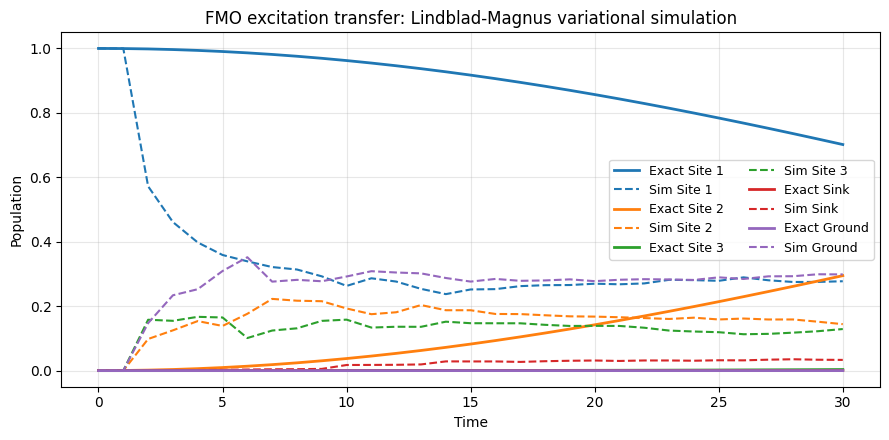

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, lab in enumerate(labels):
    ax.plot(times, exact[i], '-', color=palette[i], lw=2, label=f'Exact {lab}')
    ax.plot(times, result.expect[i], '--', color=palette[i], lw=1.5,
            label=f'Sim {lab}')
ax.set_xlabel('Time'); ax.set_ylabel('Population')
ax.set_title('FMO excitation transfer: Lindblad-Magnus variational simulation')
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. 算法内部探析

### 6.1 有效哈密顿量的 Hermitian 分解

每一步的 $H_{\mathrm{eff}}$ 是非厄米的。它的 **Hermitian 部分**
$H_R = \tfrac{1}{2}(H_{\mathrm{eff}}+H_{\mathrm{eff}}^\dagger)$ 驱动相干振荡，
**反 Hermitian 部分** $H_I = -\tfrac{i}{2}(H_{\mathrm{eff}}-H_{\mathrm{eff}}^\dagger)$
导致 norm 衰减。

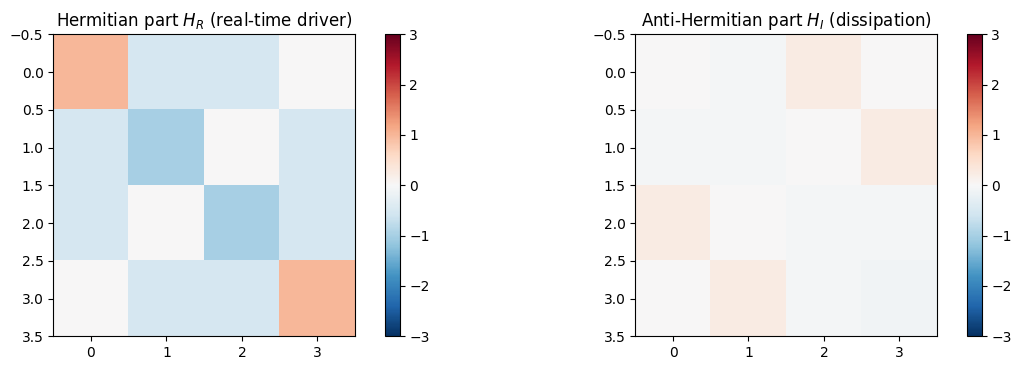

||H_R|| = 2.5032
||H_I|| = 0.5299  (non-zero → non-unitary)


In [11]:
H, c_ops, e_ops, psi0, _ = tfim_model()
dt = 0.1
integ = sample_wiener_integrals(len(c_ops), dt, rng=np.random.RandomState(42))
H_eff = effective_hamiltonian(H, c_ops, dt, magnus_order=1,
                              qsd_type='nonlinear', psi=psi0, integrals=integ)

H_R = 0.5 * (H_eff + H_eff.conj().T)
H_I = -0.5j * (H_eff - H_eff.conj().T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
im1 = ax1.imshow(H_R.real, cmap='RdBu_r', vmin=-3, vmax=3)
ax1.set_title(r'Hermitian part $H_R$ (real-time driver)')
plt.colorbar(im1, ax=ax1)
im2 = ax2.imshow(H_I.real, cmap='RdBu_r', vmin=-3, vmax=3)
ax2.set_title(r'Anti-Hermitian part $H_I$ (dissipation)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout(); plt.show()

print(f"||H_R|| = {np.linalg.norm(H_R):.4f}")
print(f"||H_I|| = {np.linalg.norm(H_I):.4f}  (non-zero → non-unitary)")


### 6.2 不同 Magnus 阶数的精度对比

更高阶的 Magnus Scheme 用更精细的随机积分修正，允许更大时间步而不损失精度。

In [12]:
H, c_ops, e_ops, psi0, _ = tfim_model()
ansatz = HardwareEfficientAnsatz(n_qubits=2, layers=2, init_state=psi0)
times = np.linspace(0, 2.0, 21)  # dt = 0.1（较大）
exact = mesolve(H, psi0, times, c_ops, e_ops)

orders = [0, 1, 2]
results = {}
for order in orders:
    solver = LindbladMagnusSolver(H, c_ops, ansatz,
                                  qsd_type='nonlinear',
                                  magnus_order=order,
                                  integrator='rk4')
    r = solver.solve(psi0, times, e_ops, traj_num=20, seed=7)
    results[order] = r
    err = np.abs(r.expect - exact).max()
    label = {0: 'Euler-Maruyama', 1: 'Magnus I', 2: 'Magnus II'}[order]
    print(f"  {label:18s} (order={order}): max err = {err:.4f}")


  Euler-Maruyama     (order=0): max err = 0.0661


  Magnus I           (order=1): max err = 0.0502


  Magnus II          (order=2): max err = 0.0943


### 6.3 Linear vs Nonlinear QSD

- **Nonlinear QSD**：波函数始终归一化，$\langle L_k\rangle$ 反馈到漂移项。系综平均
  直接给出 $\rho$。方差小，推荐默认使用。
- **Linear QSD**：波函数 norm 衰减，需要额外跟踪 $N(t)$。方差大，但某些 unravelling
  下收敛更快。

In [13]:
for qsd in ('nonlinear', 'linear'):
    solver = LindbladMagnusSolver(H, c_ops, ansatz,
                                  qsd_type=qsd, magnus_order=1, integrator='rk4')
    r = solver.solve(psi0, times, e_ops, traj_num=20, seed=11)
    print(f"{qsd:11s} QSD: max err = {np.abs(r.expect - exact).max():.4f},"
          f"  final mean std = {r.std[:, -1].mean():.4f}")


nonlinear   QSD: max err = 0.1052,  final mean std = 0.1500


linear      QSD: max err = 0.0942,  final mean std = 0.1158


### 6.4 Ansatz 参数轨迹

`evolve_trajectory(..., return_params=True)` 返回每条轨迹的完整 $\theta(t)$
演化，便于诊断变分动力学的稳定性。

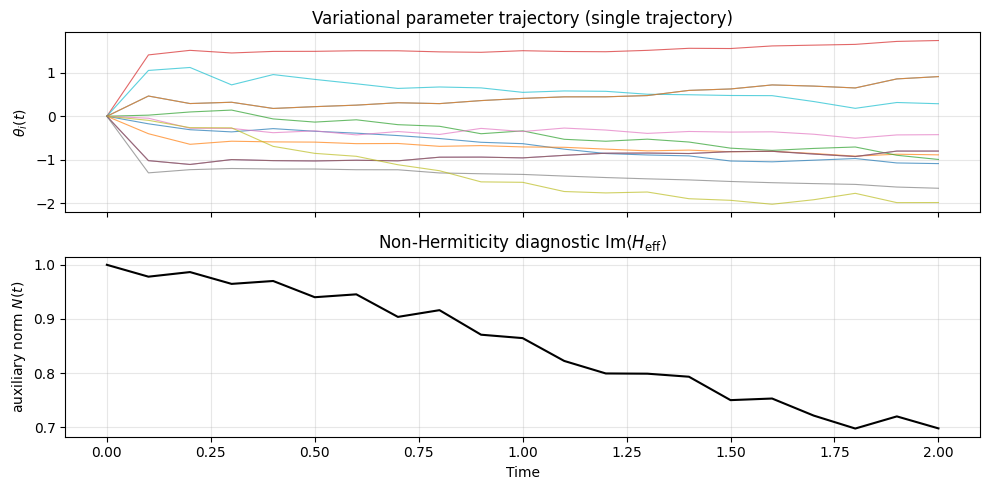

In [14]:
solver = LindbladMagnusSolver(H, c_ops, ansatz, magnus_order=1)
traj = solver.evolve_trajectory(times, e_ops, seed=0, return_params=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for i in range(ansatz.n_parameters):
    ax1.plot(times, traj['params'][:, i], lw=0.8, alpha=0.7)
ax1.set_ylabel(r'$\theta_i(t)$')
ax1.set_title('Variational parameter trajectory (single trajectory)')
ax1.grid(alpha=0.3)

ax2.plot(times, traj['norm'], color='k', lw=1.5)
ax2.set_xlabel('Time'); ax2.set_ylabel(r'auxiliary norm $N(t)$')
ax2.set_title(r'Non-Hermiticity diagnostic $\mathrm{Im}\langle H_{\mathrm{eff}}\rangle$')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. 高级用法

### 7.1 `LindbladResult` 结果容器

`solve()` 返回的 `LindbladResult` dataclass 携带完整元数据，便于后续分析与
可重复研究。

In [15]:
result = solver.solve(psi0, times, e_ops, traj_num=5, seed=3)
print(f"Result type:        {type(result).__name__}")
print(f"  expect.shape:     {result.expect.shape}")
print(f"  std.shape:        {result.std.shape}")
print(f"  norms.shape:      {result.norms.shape}")
print(f"  traj_num:         {result.traj_num}")
print(f"  seeds[:3]:        {result.seeds[:3]}")
print(f"  solver_info:      {result.solver_info}")


Result type:        LindbladResult
  expect.shape:     (3, 21)
  std.shape:        (3, 21)
  norms.shape:      (21,)
  traj_num:         5
  seeds[:3]:        [3, 213, 423]
  solver_info:      {'qsd_type': 'nonlinear', 'magnus_order': 1, 'integrator': 'rk4', 'nonlinear_corr': False, 'n_c_ops': 2, 'n_params': 12, 'eps': 1e-12}


### 7.2 自定义 ansatz

通过 `VariationalAnsatz` 可以构建任意拓扑的参数化线路：

In [16]:
from pyqpanda3.core import RX, RY, RZ, CNOT

custom = VariationalAnsatz(n_qubits=2, init_state=psi0)
# 一层自定义结构
custom.add_gate(RY, 0)            # theta[0]
custom.add_gate(RY, 1)            # theta[1]
custom.add_gate(CNOT, (0, 1))     # static entangler
custom.add_gate(RZ, 0)            # theta[2]
custom.add_gate(RZ, 1)            # theta[3]
custom.add_gate(CNOT, (0, 1))     # un-entangle at theta=0
print(f"Custom ansatz: {custom!r}")
print(f"State at theta=0 matches psi0: "
      f"{np.allclose(custom.get_statevector(np.zeros(4)), psi0)}")


Custom ansatz: VariationalAnsatz(n_qubits=2, n_parameters=4, n_gates=6)
State at theta=0 matches psi0: True


### 7.3 并行执行

`n_jobs > 1` 时启用多进程并行，ansatz 通过 `__getstate__` 自动剥离不可序列化
的 `CPUQVM`，子进程内重建。

> **注意**：在某些 macOS / Windows 环境下，Python 默认使用 `spawn` 启动
> 方式，要求主模块可被重新导入。在 Jupyter notebook 中这一点由
> `ipykernel` 自动处理；在 `.py` 脚本中请将调用放在
> `if __name__ == "__main__":` 保护块内。若并行启动失败，solver 会自动
> 回退到串行执行并发出 warning。

In [17]:
import time
solver = LindbladMagnusSolver(H, c_ops, ansatz, magnus_order=1)

t0 = time.time()
r_serial = solver.solve(psi0, times, e_ops, traj_num=8, seed=0, n_jobs=1)
t_serial = time.time() - t0

t0 = time.time()
r_parallel = solver.solve(psi0, times, e_ops, traj_num=8, seed=0, n_jobs=4)
t_parallel = time.time() - t0

print(f"Serial:   {t_serial:.2f}s")
print(f"Parallel: {t_parallel:.2f}s  (n_jobs=4)")
print(f"Results identical: {np.allclose(r_serial.expect, r_parallel.expect)}")


Serial:   0.85s
Parallel: 22.19s  (n_jobs=4)
Results identical: True


### 7.4 Predictor-Corrector（`nonlinear_corr=True`）

启用后，漂移项用 $\tfrac{1}{2}(\langle L\rangle_\psi + \langle L\rangle_{\psi_p})$
替代单纯的 $\langle L\rangle_\psi$，提升非线性 QSD 在大时间步下的稳定性。

In [18]:
plain = LindbladMagnusSolver(H, c_ops, ansatz, nonlinear_corr=False)
corr  = LindbladMagnusSolver(H, c_ops, ansatz, nonlinear_corr=True)

r_plain = plain.solve(psi0, times, e_ops, traj_num=10, seed=21)
r_corr  = corr.solve (psi0, times, e_ops, traj_num=10, seed=21)
print(f"plain:        max err = {np.abs(r_plain.expect - exact).max():.4f}")
print(f"corrected:    max err = {np.abs(r_corr.expect  - exact).max():.4f}")
print(f"trajectories differ: {not np.allclose(r_plain.expect, r_corr.expect)}")


plain:        max err = 0.1843
corrected:    max err = 0.1696
trajectories differ: True


## 8. 参数调优指南

### 8.1 时间步 `dt`

建议 $\Delta t \approx 0.05 \sim 0.1 \cdot \tfrac{2\pi}{\|H\|}$。过大时 McLachlan
最小二乘病态，表现为 `Ground` / `Sink` 等通道人口过冲。可调大 `eps` 缓解。

In [19]:
H_norm = np.linalg.norm(H)
print(f"||H|| = {H_norm:.3f}")
print(f"Recommended dt range: [{0.05 * 2*np.pi / H_norm:.3f},"
      f" {0.1 * 2*np.pi / H_norm:.3f}]")


||H|| = 2.449
Recommended dt range: [0.128, 0.257]


### 8.2 Ansatz 层数与轨迹数

下面用 TFIM 在固定 `dt=0.05` 下扫描 ansatz 深度和轨迹数对精度的影响。

In [20]:
scan_times = np.linspace(0, 1.5, 16)
scan_exact = mesolve(H, psi0, scan_times, c_ops, e_ops)

print("Layer scan (traj_num=10):")
for layers in [1, 2, 3]:
    ans = HardwareEfficientAnsatz(n_qubits=2, layers=layers, init_state=psi0)
    solver = LindbladMagnusSolver(H, c_ops, ans)
    r = solver.solve(psi0, scan_times, e_ops, traj_num=10, seed=5)
    print(f"  layers={layers}: {ans.n_parameters:2d} params,"
          f"  max err = {np.abs(r.expect - scan_exact).max():.4f}")

print("\nTrajectory scan (layers=2):")
ans = HardwareEfficientAnsatz(n_qubits=2, layers=2, init_state=psi0)
solver = LindbladMagnusSolver(H, c_ops, ans)
for tn in [5, 10, 20, 50]:
    r = solver.solve(psi0, scan_times, e_ops, traj_num=tn, seed=5)
    print(f"  traj_num={tn:3d}: max err = {np.abs(r.expect - scan_exact).max():.4f},"
          f"  mean std = {r.std.mean():.4f}")


Layer scan (traj_num=10):


  layers=1:  6 params,  max err = 0.1152


  layers=2: 12 params,  max err = 0.0711


  layers=3: 18 params,  max err = 0.0377

Trajectory scan (layers=2):


  traj_num=  5: max err = 0.0724,  mean std = 0.0712


  traj_num= 10: max err = 0.0711,  mean std = 0.0820


  traj_num= 20: max err = 0.0686,  mean std = 0.0787


  traj_num= 50: max err = 0.0794,  mean std = 0.1038


### 8.3 选择 `eps` 正则化

若日志中出现 `LinAlgError` 或结果发散，调大 `eps`（默认 `1e-12`）。

In [21]:
for eps in [1e-12, 1e-10, 1e-8, 1e-6]:
    solver = LindbladMagnusSolver(H, c_ops, ans, eps=eps)
    r = solver.solve(psi0, scan_times, e_ops, traj_num=5, seed=5)
    print(f"  eps={eps:.0e}: max err = {np.abs(r.expect - scan_exact).max():.4f}")


  eps=1e-12: max err = 0.0724


  eps=1e-10: max err = 0.2543


  eps=1e-08: max err = 0.0448


  eps=1e-06: max err = 0.0557


## 9. 拓展：自由基对模型（RPM）

自由基对模型描述鸟类磁感应的 singlet-triplet 自旋动力学。本模块提供的
`rpm_model()` 使用**归一化单位**（`omega=1.0`），可直接用于默认 solver 设置。

RPM H shape: (8, 8), c_ops: 6, e_ops: ['Singlet product', 'Triplet product']


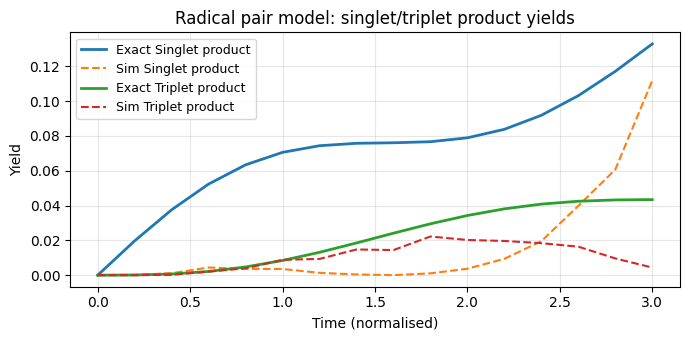

In [22]:
H_rpm, c_ops_rpm, e_ops_rpm, psi0_rpm, labels_rpm = rpm_model()
print(f"RPM H shape: {H_rpm.shape}, c_ops: {len(c_ops_rpm)}, e_ops: {labels_rpm}")

ansatz_rpm = HardwareEfficientAnsatz(n_qubits=3, layers=1, init_state=psi0_rpm)
solver_rpm = LindbladMagnusSolver(H_rpm, c_ops_rpm, ansatz_rpm)

times_rpm = np.linspace(0, 3, 16)
exact_rpm = mesolve(H_rpm, psi0_rpm, times_rpm, c_ops_rpm, e_ops_rpm)
result_rpm = solver_rpm.solve(psi0_rpm, times_rpm, e_ops_rpm,
                               traj_num=10, seed=0)

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, lab in enumerate(labels_rpm):
    ax.plot(times_rpm, exact_rpm[i], '-', lw=2, label=f'Exact {lab}')
    ax.plot(times_rpm, result_rpm.expect[i], '--', lw=1.5, label=f'Sim {lab}')
ax.set_xlabel('Time (normalised)'); ax.set_ylabel('Yield')
ax.set_title('Radical pair model: singlet/triplet product yields')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. 总结与扩展

### 本教程覆盖

1. ✅ Lindblad / QSD / Magnus / McLachlan 的完整理论链路
2. ✅ `mesolve` 精确解参考（替代 `qutip.mesolve`）
3. ✅ TFIM 阻尼 + FMO 光合复合体 + RPM 三个端到端案例
4. ✅ 算法内部诊断：$H_{\mathrm{eff}}$ 分解、Magnus 阶数对比、参数轨迹
5. ✅ 高级 API：`LindbladResult`、自定义 ansatz、并行、predictor-corrector
6. ✅ 系统性参数调优指南

### 进阶建议

| 场景 | 建议 |
| --- | --- |
| 长时间 FMO 传输 | 使用 Hamiltonian Variational Ansatz（按 $H$ 的 Pauli 项构造） |
| 大比特数 | 增大 `n_jobs`，降低 `layers`，或采用 `sparse` 矩阵后端 |
| 强耗散系统 | 启用 `nonlinear_corr=True`，减小 `dt` |
| 硬件执行 | 通过 `ansatz.to_qprog()` 导出 QProg，转译到目标后端 |

### 引用

如果本模块对您的研究有帮助，请引用：

```bibtex
@article{Huang2025LindbladMagnus,
  title   = {Towards Robust Variational Quantum Simulation of Lindblad
             Dynamics via Stochastic Magnus Expansion},
  author  = {Huang, Jia-Cheng and Li, Hao-En and Wang, Yi-Cheng
             and Zhang, Guang-Ze and Li, Jun and Hu, Han-Shi},
  journal = {PRX Quantum},
  volume  = {6},
  pages   = {040312},
  year    = {2025},
  doi     = {10.1103/yyln-q22s},
}
```
